In [1]:
import opticalib
import matplotlib.pyplot as plt
import os
from astropy.io import fits

import xupy as xp

from opticalib.ground.modal_decomposer import ZernikeFitter


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 5060`
       Memory = 7884.61 MB | Compute Capability = 12.0
       Using CuPy 13.6.0 for acceleration.


In [2]:
path = '/mnt/backup/alpao468/OPTData/INTMatrices/20260326_100417'
IMcube = xp.array(fits.getdata(os.path.join(path, 'IMCube.fits')))

mask = xp.zeros([IMcube.shape[0],IMcube.shape[1]], dtype=bool)
for j in range(IMcube.shape[-1]):
    mask = xp.logical_or(mask, IMcube[:,:,j]==0)

IM = xp.zeros([IMcube.shape[-1],int(xp.sum(1-mask))], dtype=float)
for j in range(IMcube.shape[-1]):
    IM[j,:] = IMcube[:,:,j].copy()[~mask]
cMat = xp.array(fits.getdata(os.path.join(path, 'cmdMatrix.fits')))

del IMcube

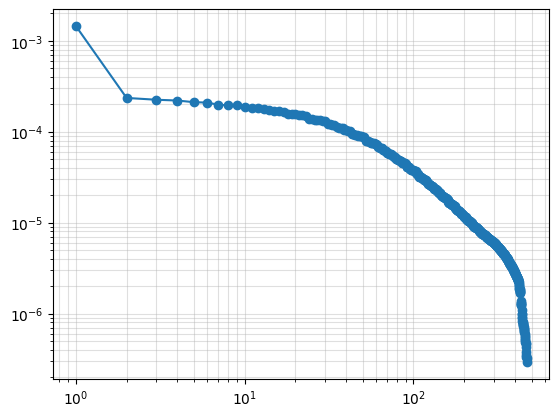

In [3]:
IF = xp.linalg.pinv(cMat) @ IM

S = xp.linalg.svd(IF, compute_uv=False)

plt.figure()
plt.loglog(xp.arange(1, len(S)+1).get(), S.get(), '-o')
plt.grid(which='both',alpha=0.4)

In [4]:
zf = ZernikeFitter(fit_mask=mask.get())

ZM = xp.vstack([xp.array(zf._get_mode_from_generator(j)[~mask.get()]) for j in range(2, 29)])

tip = xp.array(zf._get_mode_from_generator(2)[~mask.get()])
tilt = xp.array(zf._get_mode_from_generator(3)[~mask.get()])


R = xp.linalg.pinv(IF.T)

# U,S,Vt = xp.linalg.svd(IF.T, full_matrices=False)
# R = Vt.T * xp.diag(1/S) @ U.T
# S_inv = S/(S**2+1e-5**2)
# Rtiko = (Vt.T *  xp.diag(S_inv)) @ U.T
# print(tilt.shape,tip.shape,IF.shape,R.shape,Rtiko.shape)

ZCM = ZM @ IF.T

# S = xp.linalg.svd(ZCM, compute_uv=False)

# plt.figure()
# plt.loglog(xp.arange(1, len(S)+1).get(), S.get()**2, '-o')
# plt.grid(which='both',alpha=0.4)

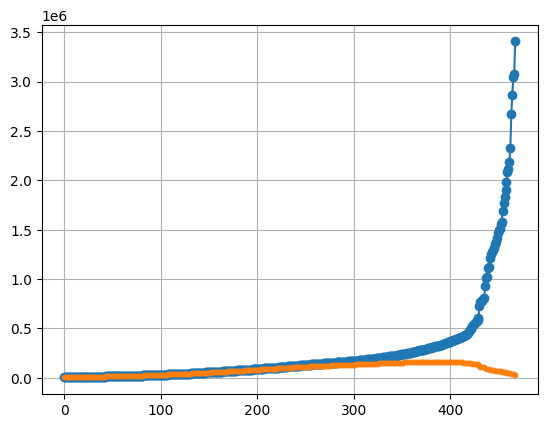

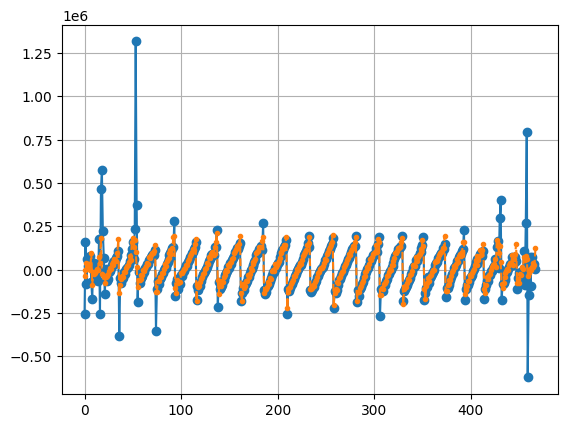

In [5]:


# c_tilt_clip = Rtiko @ tilt
# c_tip_clip = Rtiko @ tip
import numpy as np

U,S,Vt = np.linalg.svd((IF.T).get(), full_matrices=False)
R = xp.array(Vt.T @ np.diag(1/S) @ U.T)
S_inv = S/(S**2+1e-11)
Rtiko = xp.array((Vt.T @ np.diag(S_inv)) @ U.T)

plt.figure()
plt.plot(1/S,'-o')
plt.plot(S_inv,'--.')
plt.grid()

c_tilt = R @ tilt
c_tip = R @ tip

c_tilt_clip = Rtiko @ tilt
c_tip_clip = Rtiko @ tip

plt.figure()
plt.plot(c_tilt.get(),'-o')
plt.plot(c_tilt_clip.get(),'--.')
# plt.plot(c_tip.get(), '-o')
# plt.plot(c_tip_clip.get(), '--.')
plt.grid()

from numpy.ma import masked_array
def reshape_on_mask(vec,mask,show:bool=False):
    out = xp.zeros(mask.shape, dtype=float)
    out[~mask] = vec
    if show:
        plt.figure()
        plt.imshow(masked_array(out.get(),mask=mask.get()), origin='lower', cmap='RdBu')
        rms = xp.std(out)
        pv = xp.max(out)-xp.min(out)
        plt.colorbar()
        plt.title(f'RMS: {rms*1e+6:1.2f} '+r'[$\mu m$], PV: '+f'{pv*1e+6:1.2f} '+r'[$\mu m$]')
    return out


In [6]:
# IFn = IF - xp.mean(IF,axis=1)[:,None]
# K = IFn @ IFn.T

# plt.figure()
# plt.imshow(K.get())
# plt.colorbar()



In [7]:
max_tilt = xp.max(xp.abs(c_tilt))
max_tip = xp.max(xp.abs(c_tip))
max_tilt_clip = xp.max(xp.abs(c_tilt_clip))
max_tip_clip = xp.max(xp.abs(c_tip_clip))

# get the second largest value
max_tilt_2nd = xp.partition(xp.abs(c_tilt_clip), -2)[-2]
max_tip_2nd = xp.partition(xp.abs(c_tip_clip), -2)[-2]

rms2PV = 4
sf2wf = 2
print(f'max tilt: {1/max_tilt_2nd*rms2PV*sf2wf:.2e}, max tip: {1/max_tip_2nd*rms2PV*sf2wf:.2e}')
print(f'max tilt clip: {1/max_tilt_clip*rms2PV*sf2wf:.2e}, max tip clip: {1/max_tip_clip*rms2PV*sf2wf:.2e}')

max tilt: 3.82e-05, max tip: 2.46e-05
max tilt clip: 3.62e-05, max tip clip: 1.98e-05


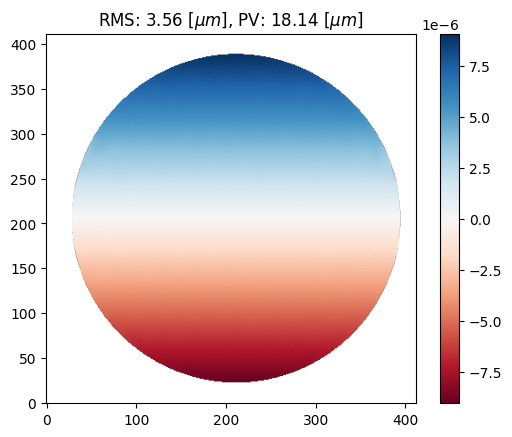

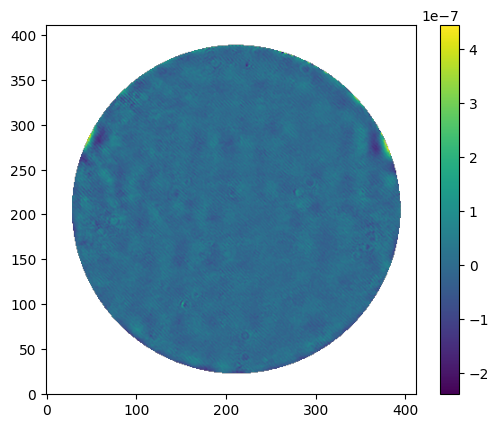

In [8]:
ztilt = reshape_on_mask(tilt, mask, show=False)
tiltvec = reshape_on_mask(IF.T @ c_tilt/max_tilt_clip, mask, show=False)
ctiltvec = reshape_on_mask(IF.T @ c_tilt_clip/max_tilt_clip, mask, show=True)

plt.figure()
plt.imshow(masked_array((ztilt/max_tilt_clip-ctiltvec).get(),mask=mask.get()), origin='lower')
plt.colorbar()

0.0070827814706424


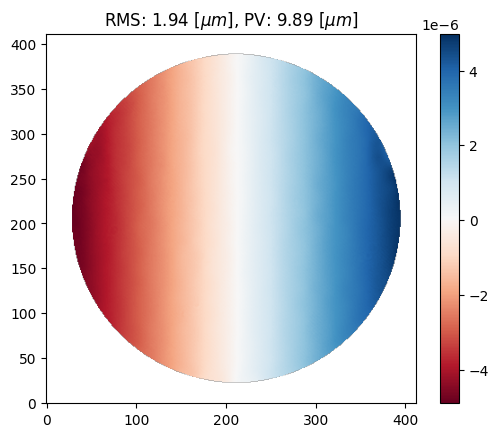

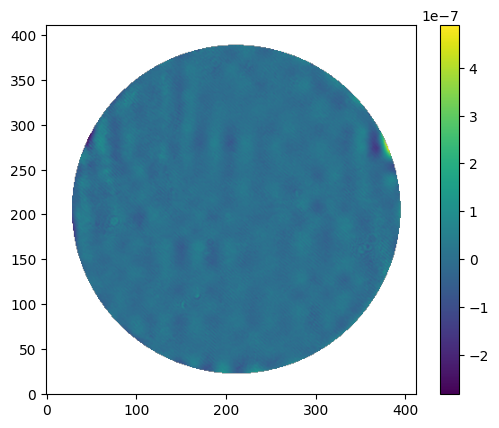

In [9]:
ztip = reshape_on_mask(tip, mask, show=False)
tipvec = reshape_on_mask(IF.T @ c_tip/max_tip_clip, mask, show=False)
ctipvec = reshape_on_mask(IF.T @ c_tip_clip/max_tip_clip, mask, show=True)

plt.figure()
plt.imshow(masked_array((ztip/max_tip_clip-ctipvec).get(),mask=mask.get()), origin='lower')
print(xp.std((ztip/max_tip_clip-ctipvec)*max_tip_clip))
plt.colorbar()

In [ ]:
focus = xp.array(zf._get_mode_from_generator(4)[~mask.get()])
c_focus = R @ focus
c_focus_clip = Rtiko @ focus

max_focus = xp.max(xp.abs(c_focus))
max_focus_clip = xp.max(xp.abs(c_focus_clip))

focusvec = reshape_on_mask(IF.T @ c_focus/max_focus_clip, mask, show=False)
cfocusvec = reshape_on_mask(IF.T @ c_focus_clip/max_focus_clip, mask, show=True)

plt.figure()
plt.imshow(masked_array((focusvec-cfocusvec).get(),mask=mask.get()), origin='lower')
plt.colorbar()

In [ ]:
# import numpy as np
# from scipy.ndimage import shift, center_of_mass
# from skimage.registration import phase_cross_correlation

# def estimate_actuator_positions(IF, mask, threshold=1e-6):
#     """
#     Finds the sub-pixel coordinates and peak amplitudes of DM actuators.
    
#     Parameters:
#     - interaction_matrix: 2D numpy array of shape (P, A), where P is the 
#                           number of pixels and A is the number of actuators.
#     - grid_shape: Tuple (ny, nx) representing the 2D shape of the pupil image.
#     - threshold: Float representing the L2 norm cutoff to select "well inside" 
#                  actuators to build the master average shape.
                 
#     Returns:
#     - peaks: 1D array of length A containing the fitted peak amplitudes.
#     - coords: 2D array of shape (A, 2) containing (y, x) sub-pixel coordinates.
#     """
#     interaction_matrix = IF.T.get()
#     _, n_actuators = interaction_matrix.shape

#     if_cube = np.zeros((mask.shape[0], mask.shape[1], n_actuators), dtype=float)
#     for i in range(n_actuators):
#         if_cube[:, :, i] = reshape_on_mask(IF[i,:], mask, show=False).get()

#     # 2. Identify actuators "well inside" the pupil using the L2 Norm
#     norms = np.linalg.svd(interaction_matrix, compute_uv=False)
#     valid_idx = np.where(norms > threshold)[0]
    
#     if len(valid_idx) == 0:
#         raise ValueError("Threshold is too high; no actuators selected for averaging.")
        
#     print(f"Using {len(valid_idx)} actuators to build the master Average IF.")

#     # 3. Build the Master Average Influence Function
#     # We must align them to sub-pixel accuracy BEFORE averaging so we don't blur the peak.
#     # We'll use the strongest actuator as our initial "seed" template.
#     # seed_idx = valid_idx[np.argmax(norms)]   
#     # seed_img = if_cube[:, :, seed_idx]
    
#     # aligned_ifs = []
#     # for idx in valid_idx:
#     #     img = if_cube[:, :, idx]
#     #     # Find sub-pixel shift to align 'img' to 'seed_img'
#     #     shift_vals, _, _ = phase_cross_correlation(seed_img, img, upsample_factor=10)
#     #     # Shift the image to match the seed
#     #     shifted_img = shift(img, shift_vals, order=3, mode='constant', cval=0.0)
#     #     aligned_ifs.append(shifted_img)
        
#     # if_master = np.mean(aligned_ifs, axis=0)

#     if_master = if_cube[:, :, 200]

#     plt.figure()
#     plt.imshow(if_master, origin='lower')
#     plt.colorbar()
    
#     # Find the exact sub-pixel center of our new master average IF
#     # Squaring it ensures we localize the peak accurately even if there are negative ripples
#     cy_avg, cx_avg = center_of_mass(np.abs(if_master)**2)

#     # 4. Fit the Master Average to ALL actuators (including partial ones)
#     peaks = np.zeros(n_actuators)
#     coords = np.zeros((n_actuators, 2))
    
#     for i in range(n_actuators):
#         img = if_cube[:, :, i]
        
#         # Cross-correlate master to the current actuator
#         # upsample_factor=100 gives 0.01 pixel resolution
#         shift_vals, _, _ = phase_cross_correlation(if_master, img, upsample_factor=4)
        
#         # shift_vals is the translation needed to register 'img' with 'master_avg_if'
#         # Therefore, the actual coordinate is the master center minus the shift
#         act_y = cy_avg - shift_vals[0]
#         act_x = cx_avg - shift_vals[1]
#         coords[i] = [act_y, act_x]
        
#         # To find the true amplitude, we shift the master to sit exactly over the actuator
#         # and perform a linear least-squares fit.
#         aligned_master = shift(if_master, -shift_vals, order=3, mode='constant', cval=0.0)
        
#         # Fit: img ~ peak * aligned_master
#         # Using dot product math: peak = (img • aligned_master) / (aligned_master • aligned_master)
#         peak = np.sum(img * aligned_master) / np.sum(aligned_master**2)
#         peaks[i] = peak

#     return peaks, coords

Text(0.5, 1.0, 'Stiffness [$V/\\mu m$]')

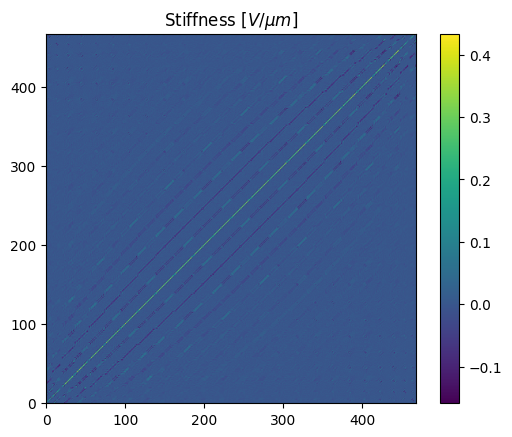

In [ ]:
IFn = IF - np.mean(IF,axis=1)[:,None]
act_pos = np.argmax(IF,axis=1)

C = IFn[:,act_pos]
K = xp.linalg.pinv(C,rcond=0.05)

# plt.figure()
# plt.imshow(C.get())
# plt.colorbar()

plt.figure()
plt.imshow(K.get()/1e+6)
plt.colorbar()
plt.title(r'Stiffness [$V/\mu m$]')

In [ ]:
thr = 0.2*xp.max(IF)
slave_ids = xp.where(xp.max(IF,axis=1)<thr)[0]
master_ids = xp.where(xp.max(IF,axis=1)>=thr)[0]

Kss = K[slave_ids][:,slave_ids]
Ksm = K[slave_ids][:,master_ids]
Kms = K[master_ids][:,slave_ids]
Kmm = K[master_ids][:,master_ids]

Qs = -xp.linalg.pinv(Kms.T @ Kms + Kss.T @ Kss) @ (Kms.T @ Kmm + Kss.T @ Ksm)

print(IF.shape,Qs.shape)

# Slaved matrices
IFslaved = IF[master_ids,:].T + IF[slave_ids,:].T @ Qs 
Kslaved = Kmm + Kms @ Qs

(468, 104910) (6, 462)


OutOfMemoryError: Out of memory allocating 387,747,840 bytes (allocated so far: 3,673,994,240 bytes).